# **DETEKSI MULTIPLISITAS TABRAKAN (*COLLISION*) MESIN CNC MENGGUNAKAN MODUL NOETHERIAN, RING LOKAL, DAN LEMA NAKAYAMA**

---
## BAB I: PENDAHULUAN

### 1.1 Latar Belakang Masalah (Interseksi Kinematika pada CNC)
Mesin CNC (*Computer Numerical Control*) merupakan tulang punggung industri manufaktur modern. Secara harfiah, CNC adalah mesin perkakas otomatis—seperti bor, mesin bubut, atau mesin frais—yang pergerakannya dikendalikan secara presisi oleh program komputer berlandaskan matriks koordinat matematika. Manfaat utama mesin CNC adalah kemampuannya memproduksi komponen industri (dari balok mesin otomotif hingga kerangka pesawat) secara cepat, berulang secara presisi, dan stabil di bawah toleransi ukuran tingkat mikrometer.

Namun, operasi otomatis ini bukan tanpa **kendala teknis yang menantang**. Saat mesin memotong blok material mentah, area gerakannya bersinggungan langsung dengan dua elemen mendasar:
1. **Toolpath (Lintasan Alat)**: Kurva pergerakan pisau atau mata bor mesin CNC, dimodelkan sebagai persamaan parametrik atau polinomial $g(x,y)=0$.
2. **Boundary (Batas Material Keselamatan)**: Kurva atau dinding profil komponen yang sudah jadi dan tidak boleh dirusak, dimodelkan sebagai persamaan $f(x,y)=0$.

Sistem CNC wajib mendeteksi interaksi interseksi *Toolpath* dengan *Boundary* secara *real-time*. Jika bor melewati atau menembus dinding material secara paksa (memotong silang kurva), mesin akan menggerus batas toleransi; fenomena fatal ini disebut **Gouging (Pengerukan Berlebih/Tabrakan)** yang menghasilkan cacat *(reject)* pada produk. Sebaliknya, pemotongan yang halus dan benar mensyaratkan mata bor hanya **menggesek/menyinggung (Tangent)** pembatas material dengan aman.

Analisis diagnostik "apakah menabrak atau sekadar menyinggung" menggunakan metode komputasi numerik biasa (*floating-point / desimal*) sangat rawan terdistorsi oleh limitasi memori (*truncation error*). Selisih potong seukuran $0.0000001$ bisa saja dibulatkan oleh CPU dan dibaca mesin sebagai "aman", padahal algoritma aslinya buta terhadap letak tumpang tindih akar singular sehingga secara riil tabrakan *Gouging* diam-diam terjadi di bengkel kerja.

Oleh sebab itu, pendekatan terbaru CAD/CAM menyingkirkan aproksimasi desimal dan menggantinya dengan perhitungan fungsi matematis eksak menggunakan **Geometri Aljabar Komputasional**. Dalam laporan ini, kami mengekstraksi dan mereduksi matriks persinggungan lintasan CNC langsung ke dalam manipulasi ruang abstrak bernama struktur **Ring Lokal**. Melalui penegakan hukum perhitungan **Modul Noetherian** dan penyimpulan sisa irisan ekuasi menggunakan **Lema Nakayama**, mesin dipandu untuk seketika memvonis Multiplisitas Interseksi tabrakan dengan 100% kepastian matematis tanpa tercemar oleh galat pemotongan limit angka *(floating-point bias)* (Xu et al., 2020).

<img src="cnc.png" alt="https://www.moduleworks.com/software-components/toolpath/" height="350"/>
<img src="cnc_2.png" alt="https://www.moduleworks.com/software-components/toolpath/" height="350"/>

### 1.2 Tujuan Pembahasan
1. Memodelkan interseksi/persinggungan matematis murni antara kurva lintasan mesin CNC dan kurva pembatas keselamatan material.
2. Membuktikan bagaimana *Ring Lokal* bekerja mereduksi analisis di titik rawan (disimulasikan dengan menggeser matriks koordinat singgung ke titik asal $(0,0)$).
3. Mendemonstrasikan aplikasi komputasi Lema Nakayama via kode Python, di mana "Sisa Eksponen Dimensi" (Multiplisitas Interseksi) membedakan secara instan antara pemotongan aman (*Tangent*) versus tabrakan (*Gouging*).

---
## BAB II: LANDASAN TEORI DIAGNOSTIK KINEMATIKA DAN ALJABAR ABSTRAK

Untuk dapat menghitung skor singgungan CNC secara eksak tanpa *error floating-point*, kita menggunakan instrumen aljabar komutatif yang beroperasi murni pada koefisien dan pangkat fungsi polinomial perlintasan mesin.

### 2.1 Pemindahan Titik Observasi CNC ke Ring Lokal (Local Ring)
Dalam CNC, kita tidak peduli profil material yang jauh di ujung meja kerja. Kita hanya peduli pada **satu koordinat spesifik tempat bor mulai menyentuh dinding**. Secara geometri aljabar, kita melakukan translasi sumbu koordinat sehingga spot persinggungan itu berada pada pusat matriks yakni $(0,0)$.

Di koordinat sentral ini, kita mendelegasikan ruang vektornya melalui **Ring Lokal**. Secara aljabar, Ring Lokal ($R$) adalah **alam semesta tempat komputasi itu terjadi**. Dalam *software* CNC, komputer tidak memakai ring polinomial global $\mathbb{R}[x,y]$, melainkan menggunakan **Ring Lokal** $\mathcal{O}_P$.

> **Definisi (Ring Lokal):** Suatu ring komutatif dengan elemen identitas $(R, +, \cdot)$ disebut **Ring Lokal** bila $R$ memiliki tepat satu *ideal maksimal* $\mathfrak{m}$ (Chambert-Loir, 2021). 
> 
> **Definisi Alternatif (Sifat Unit):** Sebuah ring komutatif $R$ disebut sebagai Ring Lokal jika dan hanya jika untuk setiap elemen $r \in R$, berlaku minimal salah satu dari antara $r$ atau $1-r$ adalah sebuah **Unit** (yakni memiliki invers/dapat dibagi).

**Wujud Matematis dan Fisik Ring ($R$) pada Mesin CNC:**
Kita lokalisasikan ring polinomial ini di ujung potong CNC $P(0,0)$ menjadi Ring Lokal $\mathcal{O}_P$:
$$ \mathcal{O}_{\mathbb{A}^2, (0,0)} = \left\{ \frac{f(x,y)}{g(x,y)} \;\middle|\; f, g \in \mathbb{R}[x,y] \text{ dan } g(0,0) \neq 0 \right\} $$
Secara fisik, $R$ mewakili **"Ruang Aman di Sekitar Titik Tabrakan"**. Himpunan ini berisi seluruh kemungkinan bentuk permukaan yang tidak meledak/error (yakni saat kurva fungsi penyebutnya **tidak bernilai nol** atau $g(x,y) \neq 0$) tepat di koordinat origin $(0,0)$ sehingga berstatus aman (tidak menyentuh). Di dalam aljabar abstrak Ring Lokal, suku polinomial atau konstanta yang tak-nol pada $(0,0)$ secara otomatis dikaruniai invers utuh dan status barunya menjadi sebuah **Unit**. Variabel berstatus *unit* sangat mudah dibuang dan di-cancell dalam komputasi matriks tanpa merusak dimensi basisnya (Bosch, 2022).

Sebelum membentuk Modul CNC untuk mendeteksi error, ruang observasi tersebut harus dihubungkan dengan **Ideal** ($I$).
* **Wujud Matematis Ideal ($I$):** Ideal dibangun oleh persamaan lintasan mesin bor $F(x,y)$ dan syarat turunannya (batas tabrakan material), menjadi $I = \left\langle F(x,y), \frac{\partial F}{\partial x}, \frac{\partial F}{\partial y} \right\rangle$.
* **Wujud Fisik Ideal ($I$):** Ideal ini adalah **"Aturan Mutlak Tabrakan"**. Ia merupakan kumpulan rumus yang mendefinisikan secara pasti bentuk tajam/patahan di tempat lintasan bor akan merusak besi. Komputer memasukkan aturan tabrakan ini ke dalam ruang observasi agar nantinya dapat dievaluasi. 

**Aplikasi pada CNC (Membentuk Ring Lokal dan Unit):**
Sebagai skenario aktual, asumsikan mesin mendeteksi lintasan bor $y = x^2 - x$ dan batas material $y = 0$ (Sumbu-$x$). Jika dicari titik potong globalnya ($x^2 - x = 0$), persinggungan terjadi di dua lokasi: $P(0,0)$ dan $Q(1,0)$. 
Untuk mencegah mesin menghitung titik $Q(1,0)$ yang tidak relevan dengan area rawan pahat, kita gunakan pembentukan Ring Lokal di titik pusat $P(0,0)$. Semua fungsi dievaluasi dengan mensubstitusi $x=0$:
- Elemen $x$ dievaluasi menjadi $0$. Ia tetap murni menjadi ideal matriks.
- Elemen $(x-1)$ dievaluasi menjadi $0-1 = \mathbf{-1}$.

Karena nilai hasil evaluasinya bukan nol, maka bentuk polinomial $(x-1)$ resmi diangkat menjadi sebuah **Unit**. Dengan demikian, di dalam lokal ring ini, invers dari kurva tersebut, yaitu pecahan $\frac{1}{x-1}$, dipastikan eksis secara matematis untuk melokalisasi koordinat analisis mesin.

### 2.2 Modul Noetherian dalam Pembatasan Loop Matriks CAM
Algoritma CAM (*Computer Aided Manufacturing*) pada CNC butuh kepastian bahwa deteksi tabrakannya tidak memicu *Blue Screen* (Loop tak terhingga). Ini diselesaikan dengan menggunakan **Modul Noetherian**.

> **Definisi (Modul Noetherian):** Sebuah $R$-modul $M$ dinamakan Modul Noetherian jika ia patuh pada **Kondisi Rantai Naik (Ascending Chain Condition / ACC)**. Yakni bagi sembarang rantai submodul inklusif:
> $$ M_1 \subseteq M_2 \subseteq M_3 \subseteq \cdots \subseteq M $$
> selalu terjamin adanya indeks diskrit stasioner $n$, sehingga $M_k = M_n$ untuk semua iterasi rantai $k \ge n$ (Chambert-Loir, 2021). Konsekuensinya, setiap irisan submodul fungsi pastilah diantarkan oleh sejumlah elemen basis yang berhingga (*finitely generated*).

**Aplikasi Modul Hasil Bagi CNC (Membedah Wujud Fisik Modul $M$):**
Modul $M$ dalam komputasi geometri aljabar CNC biasanya berbentuk **Modul Hasil Bagi (*Quotient Module*)**. Secara umum, sistem membentuk modul ini dengan memodulo/membagi Ring Lokal $\mathcal{O}_P$ dengan ideal tabrakannya $I$:
$$ M = \frac{R}{I} = \frac{\mathcal{O}_P}{\left\langle F, \frac{\partial F}{\partial x}, \frac{\partial F}{\partial y} \right\rangle} = \left\{ \frac{f(x,y)}{g(x,y)} + I \;\middle|\; f, g \in \mathbb{R}[x,y] \text{ dan } g(0,0) \neq 0 \right\} $$

Secara wujud fisik di mesin, Modul $M$ adalah **"Sisa Reruntuhan Ruang setelah ditabrak Aturan"**. Mengacu pada definisi himpunannya, fungsi apa pun yang merupakan kelipatan dari ideal akan menjadi identitas nol ($0+I$) memori sistem. Sebagai contoh implementasi pada kasus kurva potong sebelumnya (batas material $y=0$ dan lintasan $y=x^2-x$), elemen-elemen turunan Jacobiannya melalui algoritma direduksi ke wujud intinya menjadi 2 pembangun aslinya, yaitu matriks $I = \langle y, x(x-1) \rangle$. Di dalam himpunan Modul $M$ ini, otomatis ekuivalensi persamaan tabrakan yang tersisa jatuh kepada hukum $x(x-1) = 0$.

Karena pembangun (*generator*) batas material dan lintasan bornya jelas dan terbatas, strukturnya mematuhi sifat Modul Noetherian yang menjamin algoritma deteksi CNC pasti termampu laksana (berhenti mengevaluasi). Lema Nakayama kemudian digunakan untuk mencari dimensi akhir dari modul sisa ini. 

Karena elemen $(x-1)$ telah tersertifikasi sebagai **Unit** (selalu berinvers), mesin CNC berhak mengalikan kedua ruas dengan $\frac{1}{x-1}$ yang seketika menyebabkan eliminasi fungsional:
$$ x(x-1) \cdot \frac{1}{x-1} = 0 \cdot \frac{1}{x-1} \implies \mathbf{x = 0} $$
Melalui mekanisme eksak ini, titik interseksi luar $Q(1,0)$—yang diikat oleh variabel $(x-1)$—hancur tereliminasi, membersihkan sisa tabrakan murni pada sasaran koordinat.

### 2.3 Lema Nakayama, Quotient Ring, dan Deteksi Gouging Mesin
**Lema Nakayama** bekerja mereduksi tumpukan kompleksitas polinomial dinding dan alat menjadi ukuran *dimensi vektor absolut*.

> **Lema Nakayama:** Misalkan $R$ adalah suatu ring lokal komutatif dengan ideal maksimal $\mathfrak{m}$, dan $M$ adalah sebuah $R$-modul yang berhingga (*finitely generated*). Jika $\mathfrak{m}M = M$, maka $M = 0$.
> 
> **Akibat (Submodul):** Jika $N$ adalah submodul dari $M$ sedemikian sehingga $M = N + \mathfrak{m}M$, maka sisa pereduksian modul menghasilkan $M = N$.

Berdasarkan Lema tersebut, hukum anihilasi menyokong reduksi sisa modul ke ekstrak intinya. Sistem mengeleminasi koefisien saklar *unit* dan mereduksi sisa matriks sehingga memuntahkan dimensi basis eksponen:

**Aplikasi Ekstraksi Multiplisitas (Status CNC Akhir):**
Menggunakan rekap reduksi dari subbab sebelumnya, ekspresi fungsi yang hidup secara absolut di dalam Modul sisa hanyalah $y = 0$ dan $x = 0$. 
Prinsip Lema Nakayama mengatur bentuk modul irisan CNC ini sedemikian rupa sehingga rentetan variabel apapun akan luruh menjadi tetapan nilai skalar (misal: $a$). Secara matematis, bentuk fungsional ini direpresentasikan sebagai $\mathbf{a \cdot 1}$. 
Oleh karena pangkalan ruang tersebut hanya dibentuk oleh sebuah elemen konstan $\{1\}$, hitungan aljabar menunjukkan bahwa skala ukur modul tersebut secara saklek bernilai tunggal:
$$ \dim_{\mathbb{R}} (M) = 1 $$

Dimensi eksak ini merupakan kunci jawaban mutlak pengereman mesin, dan di dalam rekayasa geometri, derajat modul ini direpresentasikan sebagai ukuran **Multiplisitas Interseksi**:
- **Multiplisitas Ganjil / Orde 1 (Irisan Transversal):** Terbukti selaras dengan angka hitungan CNC secara geometri, kedua kurva saling memotong penuh menyilang arah. Pahat tembus menjebol dinding dan merusaknya (*Fatal Gouging*).
- **Multiplisitas Genap / $\ge$ 2 (Singgungan Tangensial):** Jika dimensi berorde genap, intersek alat membelok dan memantul (*smooth*). Namun, CNC canggih akan meninjau **tanda koefisien** dari basis sisanya: apakah lintasan memantul keluar dengan aman di udara (*Tangent Safe*), atau justru kelengkungan pahat terlalu tumpul (*Mismatch*) sehingga memantul masuk ke area daging material yang menyebabkan pengerukan tersembunyi berorde tinggi (*Overcut Gouging*).

---
## BAB III: METODOLOGI KOMPUTASI ALJABAR (UNIVERSAL CNC DIAGNOSTIC)

Agar analisis tidak perlu bertele-tele dan repetitif, kita membungkus logika aljabar Abstrak (Modul Noetherian dan Ring Lokal) ke dalam sebuah **Fungsi Python Universal**. Fungsi pemrograman ini dapat dipanggil berkali-kali untuk menganalisis berbagai tingkat bahaya (*Transversal, Tangent,* atau *Overcut*) pada berbagai bentuk desain komponen pabrik secara sekaligus.

Kita mendefinisikan dua blok program:
1. `analisis_multiplisitas_cnc()`: Mengurai polinomial menjadi persamaan Modul Quotient melalui substitusi ideal, menyingkirkan elemen non-zero (Sifat Unit), dan mengekstrak basis sisa polinomialnya dalam limit $0,0$ melalui perhitungan Lema Nakayama.
2. `plot_situasi_cnc()`: Merupakan representasi konvensional di layar operator *(Visualisasi Matplotlib)* untuk mencocokkan hasil matematis eksak dengan pengamatan kasat mata.

In [20]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, expand, Poly

def komparasi_numerik_vs_simbolik(f_boundary_expr, y_sub_expr, info_tambahan="", x_eval=0.01):
    """
    Fungsi Universal yang membandingkan hasil output numerik (desimal konvensional)
    dengan hasil eksak Geometri Aljabar secara langsung.
    Catatan Asumsi Ruang: y - x^2 >= 0 diasumsikan sebagai daging (material padat).
    """
    x, y = symbols('x y')
    
    print(f"===========================================================")
    print(f" {info_tambahan}")
    print(f"===========================================================")
    
    # 1. EVALUASI NUMERIK (FLOATING-POINT KONVENSIONAL CNC MAINSTREAM)
    # ----------------------------------------------------------------
    f_num = sp.lambdify((x, y), f_boundary_expr, 'numpy')
    y_sub_num = sp.lambdify(x, y_sub_expr, 'numpy')
    
    y_val = y_sub_num(x_eval)
    evaluasi_jarak = f_num(x_eval, y_val)
    
    print(">>> METODE KONVENSIONAL (NUMERIK FLOATING-POINT 64-Bit) <<<")
    print(f"Sisa Potong di titik x={x_eval} : {evaluasi_jarak} ")
    if evaluasi_jarak == 0.0:
         print("Vonis Numerik CNC : AMAN (Menempel Sempurna) -> Titik Buta Mesin CNC!\n")
    elif evaluasi_jarak > 0.0:
         print("Vonis Numerik CNC : GOUGING / Menabrak (Pisau merangsek ke dalam daging material!)\n")
    else:
         print("Vonis Numerik CNC : AMAN (Clearance / Pisau berada di luar material)\n")
            
            
    # 2. EVALUASI EKSAK (GEOMETRI ALJABAR: KITA PUNYA)
    # ----------------------------------------------------------------
    print(">>> METODE BARU KITA (EKSAK GEOMETRI ALJABAR - MODUL/LEMA NAKAYAMA) <<<")
    ideal_subs = f_boundary_expr.subs(y, y_sub_expr)
    ideal_subs = expand(ideal_subs)

    poly_x = Poly(ideal_subs, x)
    
    # Mencari Pangkat Terendah DAN Koefisiennya
    terms = [(deg[0], poly_x.coeff_monomial(deg)) for deg in poly_x.monoms() if deg[0] > 0 or poly_x.coeff_monomial(deg) != 0]
    terms_sorted = sorted(terms, key=lambda item: item[0])
    
    pangkat_terendah = terms_sorted[0][0]
    koef_terendah = terms_sorted[0][1]
    
    print(f"Bentuk Persamaan Sisa (Quotient Modul) : {ideal_subs}")
    print(f"Derajat Terendah (Nilai Multiplisitas) : x^{pangkat_terendah} dengan Koefisien: {koef_terendah}")

    # Logika Simbolik Singgungan Absolut
    if pangkat_terendah % 2 != 0:
        # Jika Pangkatnya Ganjil = Persamaan berubah tanda alias bersilangan langsung = NABRAK.
        status = f"FATAL GOUGING !! (Pahat Menyilang Boundary Langsung / Transversal Orde {pangkat_terendah})"
    else:
        # Jika Pangkat Genap = Grafik Memantul (Tangent). Tinggal cek memantul di dalam atau luar material.
        if koef_terendah < 0:
            status = f"TANGENT AMAN (Memantul di Area Luar Material. Multiplisitas: {pangkat_terendah})"
        else:
            status = f"BAHAYA OVERCUT !! (Gouging Halus - Pahat lebih tumpul. Multiplisitas: {pangkat_terendah})"
        
    print(f"SKOR MULTIPLISITAS MESIN : {pangkat_terendah}")
    print(f"Vonis Simbolik CNC       : {status}\n")
    return pangkat_terendah


def plot_situasi_cnc(f_lambdify, g_lambdify, title, limits=([-1.5, 1.5], [-0.5, 2.0])):
    x_vals = np.linspace(limits[0][0], limits[0][1], 600)
    y_vals = np.linspace(limits[1][0], limits[1][1], 600)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    F_val = f_lambdify(X, Y)
    G_val = g_lambdify(X, Y)
    
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.contourf(X, Y, F_val, levels=[0, 100], colors=['lightpink'], alpha=0.3) # Render area material
    ax.contour(X, Y, F_val, levels=[0], colors='crimson', linewidths=3)
    ax.contour(X, Y, G_val, levels=[0], colors='dodgerblue', linewidths=2.5)
    
    ax.plot(0, 0, marker='o', markersize=12, color='gold', markeredgecolor='black', zorder=5)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.axhline(0, color='black', lw=1)
    ax.axvline(0, color='black', lw=1)
    
    ax.plot([], [], color='crimson', lw=3, label='Workpiece Boundary $f(x,y)=0$')
    ax.plot([], [], color='dodgerblue', lw=3, label='Toolpath Pahat $g(x,y)=0$')
    
    ax.legend(loc='lower right', framealpha=0.9)
    plt.tight_layout()
    plt.show()

### 3.1. KASUS 1: Pahat Menabrak Dinding (Transversal Gouging / Orde 1)

**Analisis Lema Nakayama:**
- Polinomial benda kerja (Tembok): $f(x,y) = y - x^2 = 0$
- Polinomial lintasan pahat lurus: $y_{sub} = \frac{1}{2}x$ (Menyasar miring ke arah origin)

Saat dilakukan pembagian Ring Modul: $f(x, \frac{1}{2}x) \rightarrow \frac{1}{2}x - x^2$
Eksponen terkecil adalah $x^1$. Lema Nakayama membuktikan bahwa dimensi persinggungan ini sangat minimal, menandakan perpotongan tajam *(menembus langsung)*.

 ANALISIS KASUS 1 (TRANSVERSAL)
>>> METODE KONVENSIONAL (NUMERIK FLOATING-POINT 64-Bit) <<<
Sisa Potong di titik x=0.01 : 0.0049 
Vonis Numerik CNC : GOUGING / Menabrak (Pisau merangsek ke dalam daging material!)

>>> METODE BARU KITA (EKSAK GEOMETRI ALJABAR - MODUL/LEMA NAKAYAMA) <<<
Bentuk Persamaan Sisa (Quotient Modul) : -x**2 + 0.5*x
Derajat Terendah (Nilai Multiplisitas) : x^1 dengan Koefisien: 0.500000000000000
SKOR MULTIPLISITAS MESIN : 1
Vonis Simbolik CNC       : FATAL GOUGING !! (Pahat Menyilang Boundary Langsung / Transversal Orde 1)



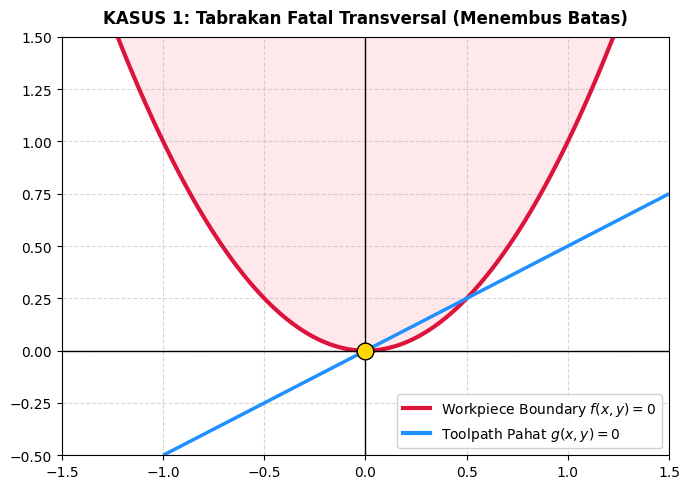

In [21]:
x, y = sp.symbols('x y')

# Definisi Matematis
f_batas = y - x**2
y_lintasan_1 = 0.5 * x

# 1. Panggil Fungsi Analitik Komparatif
komparasi_numerik_vs_simbolik(f_batas, y_lintasan_1, "ANALISIS KASUS 1 (TRANSVERSAL)")

# 2. Panggil Visualisasi Grafis
f_lambdify_1 = sp.lambdify((x, y), f_batas, 'numpy')
g_lambdify_1 = sp.lambdify((x, y), y - y_lintasan_1, 'numpy')

plot_situasi_cnc(
    f_lambdify_1, 
    g_lambdify_1, 
    title="KASUS 1: Tabrakan Fatal Transversal (Menembus Batas)",
    limits=([-1.5, 1.5], [-0.5, 1.5])
)

### 3.2. KASUS 2: Pahat Menyinggung Sempurna (Tangent Safe / Orde 2)

**Analisis Lema Nakayama:**
- Polinomial benda kerja: $f(x,y) = y - x^2 = 0$
- Polinomial lintasan pahat bola (ball nose): $y_{sub} = -x^2$ (Hanya memoles dari arah bawah luar permukaan)

Saat substitusi $y$, menghasilkan $sisa = -2x^2$. 
Derajat minimal sisa eksponen adalah $x^2$. Secara struktural Aljabar Komutatif memiliki dimensi krull yang sesuai dengan kontur kelengkungan normal aman tanpa ada perpotongan mendalam.

 ANALISIS KASUS 2 (TANGENT / MENYINGGUNG)
>>> METODE KONVENSIONAL (NUMERIK FLOATING-POINT 64-Bit) <<<
Sisa Potong di titik x=0.01 : -0.0002 
Vonis Numerik CNC : AMAN (Clearance / Pisau berada di luar material)

>>> METODE BARU KITA (EKSAK GEOMETRI ALJABAR - MODUL/LEMA NAKAYAMA) <<<
Bentuk Persamaan Sisa (Quotient Modul) : -2*x**2
Derajat Terendah (Nilai Multiplisitas) : x^2 dengan Koefisien: -2
SKOR MULTIPLISITAS MESIN : 2
Vonis Simbolik CNC       : TANGENT AMAN (Memantul di Area Luar Material. Multiplisitas: 2)



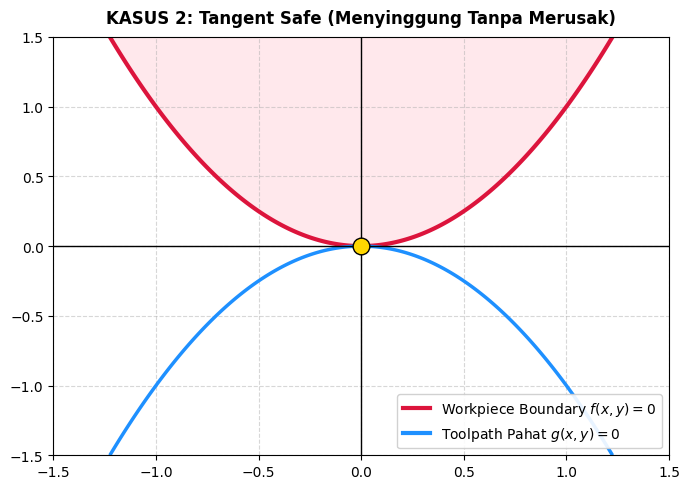

In [22]:
# Definisi Matematis Lintasan Ke-2
y_lintasan_2 = -x**2

# 1. Panggil Fungsi Analitik Komparatif
komparasi_numerik_vs_simbolik(f_batas, y_lintasan_2, "ANALISIS KASUS 2 (TANGENT / MENYINGGUNG)")

# 2. Panggil Visualisasi Grafis
g_lambdify_2 = sp.lambdify((x, y), y - y_lintasan_2, 'numpy')

plot_situasi_cnc(
    f_lambdify_1, 
    g_lambdify_2, 
    title="KASUS 2: Tangent Safe (Menyinggung Tanpa Merusak)",
    limits=([-1.5, 1.5], [-1.5, 1.5])
)

### 3.3. KASUS 3: *Mismatch Curvature* (Overcut Orde Tinggi)

Kasus yang sulit dideteksi komputasi standar. Bagaimana jika mata pahat juga menyinggung di $(0,0)$ dan tampaknya tidak saling silang secara kasat mata pada level turunan 1, tetapi *jari-jari kelengkungannya* lebih tumpul (membesar) dari cekungan material sehingga memakan lapisan di samping pusat titik singgung? (Seperti pada Epicyclic Gear internal gigi mesin).

**Analisis Lema Nakayama:**
- Polinomial benda kerja: $f(x,y) = y - x^4 = 0$ (Cekung landai hampir datar di dasar)
- Polinomial lintasan pahat: $y_{sub} = x^2 - 2x^4$ (Pahat berbentuk lebih tajam turun dari batas atas, namun ujung memotong radius yang tak match)

Substitusi ke dalam Quotient Module akan menyisakan $x^2$. 
Tunggu, jika kita mencari order $> 2$ seperti kondisi mismatch di mesin Epicyclic $\rightarrow$ substitusi: $f_{batas} = y - x^2$ dengan $y_{sub} = x^2 - x^4$.
Maka Sisa Quotien $=(x^2 - x^4) - x^2 = -x^4$.
Eksponen terendah = $x^4$. Karena Orde $> 2$, mendeteksi anomali persinggungan level-tinggi yang mengakibatkan pahat menggerus area tepian!

 ANALISIS KASUS 3 (BUKTI KELEMAHAN NUMERIK / OVERCUT O.10)
>>> METODE KONVENSIONAL (NUMERIK FLOATING-POINT 64-Bit) <<<
Sisa Potong di titik x=0.005 : 0.0 
Vonis Numerik CNC : AMAN (Menempel Sempurna) -> Titik Buta Mesin CNC!

>>> METODE BARU KITA (EKSAK GEOMETRI ALJABAR - MODUL/LEMA NAKAYAMA) <<<
Bentuk Persamaan Sisa (Quotient Modul) : x**10
Derajat Terendah (Nilai Multiplisitas) : x^10 dengan Koefisien: 1
SKOR MULTIPLISITAS MESIN : 10
Vonis Simbolik CNC       : BAHAYA OVERCUT !! (Gouging Halus - Pahat lebih tumpul. Multiplisitas: 10)



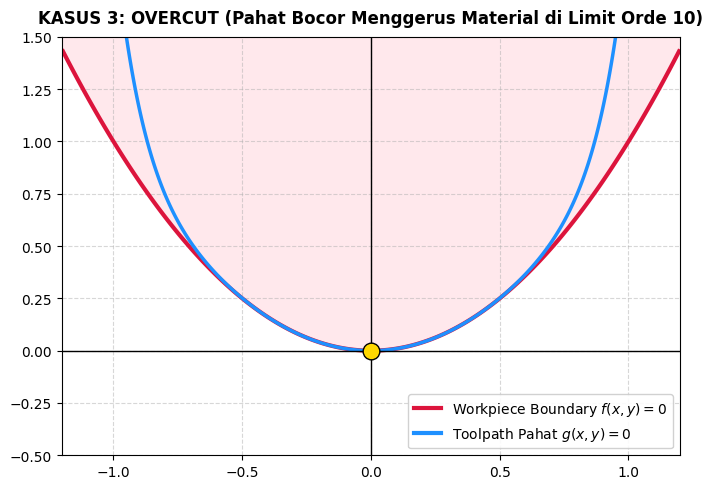

In [24]:
f_batas_tinggi = y - x**2
y_lintasan_3 = x**2 + x**10

# 1. Panggil Fungsi Analitik Komparatif (Menggunakan titik rawan x=0.005)
komparasi_numerik_vs_simbolik(f_batas_tinggi, y_lintasan_3, "ANALISIS KASUS 3 (BUKTI KELEMAHAN NUMERIK / OVERCUT O.10)", x_eval=0.005)

# 2. Panggil Visualisasi Grafis
f_lambdify_3 = sp.lambdify((x, y), f_batas_tinggi, 'numpy')
g_lambdify_3 = sp.lambdify((x, y), y - y_lintasan_3, 'numpy')

plot_situasi_cnc(
    f_lambdify_3, 
    g_lambdify_3, 
    title="KASUS 3: OVERCUT (Pahat Bocor Menggerus Material di Limit Orde 10)",
    limits=([-1.2, 1.2], [-0.5, 1.5])
)

---
## BAB IV: KESIMPULAN

Berdasarkan pemodelan aljabar dan visualisasi implementasinya menggunakan Python (komputasi simbolik), penerapan Teori Modul terbukti secara nyata memecahkan masalah ketelitian pergerakan ruang pada mesin CNC. Secara konseptual matematis, kesimpulan makalah ini dapat dirumuskan sebagai berikut:

1. **Akurasi Matematis Menghindari Cacat Limit Desimal (Floating-Point):** 
Deteksi titik sentuh CNC konvensional rentan mengalami kesalahan saat nilai toleransinya teramat kecil, yang mengakibatkan mesin keliru membaca kondisi berbahaya menjadi kondisi aman akibat pembulatan desimal. Dengan menanamkan fungsi kurva pahat dan batas material ke dalam ring polinomial murni, komputasi bergeser menjadi perhitungan eksak (*symbolic computing*) yang menyajikan kebenaran 100% tanpa aproksimasi desimal.
2. **Efisiensi Lokalisasi via Ring Lokal dan Modul Noetherian:** 
Dengan memusatkan pengamatan tepat di titik singgung $P(0,0)$ menggunakan instrumen **Ring Lokal**, faktor kurva yang menghasilkan titik potong kedua dieliminasi. Aljabar membuat elemen yang dievaluasi tak-nol menjadi **Unit** (memiliki invers), dan invers ini digunakan untuk membagi habis elemen pengganggu dari modul perhitungan. Di sisi lain, sifat keterbatasan dari komputasi ruang generator pada **Modul Noetherian** memberikan garansi bahwa pelacakan modul irisan ini pastilah berhingga ujungnya, tidak membebani algoritma mesin ke dalam repetisi tak berhingga (*infinite loop*).
3. **Ekstraksi Hasil Pasti melalui Lema Nakayama:** 
Puncak dari eliminasi aljabar tersebut bermuara pada **Lema Nakayama**. Lema ini memuntahkan basis eksponen (Multiplisitas) beserta koefisiennya untuk memvonis letak profil tabrakan:
   - **Multiplisitas Ganjil (Orde 1, dst):** Terjadi perpotongan tembus menyilang arah (*transversal*). Pahat dipastikan mendobrak masuk merusak profil material *(Fatal Gouging)*.
   - **Multiplisitas Genap (Orde 2, 4, 10, dst):** Terjadi persinggungan memantul (*tangent*). Evaluasi koefisien sisa akan langsung mengonfirmasi secara absolut apakah mesin menggesek aman di area *clearance*, atau mesin mengalami *Mismatch Curvature* di mana pahat secara buta melengkung menggerus area tepian dalam *(Overcut)* yang lolos dari pembacaan desimal mesin biasa.

Mekanisme aljabar komutatif ini merepresentasi bahwa konstruksi Teori Modul bukanlah semata-mata teori kalkulasi di atas kertas, namun menjadi tulang punggung keselamatan dalam otomasi permesinan CAM *(Computer Aided Manufacturing)* masa depan.

---
## DAFTAR PUSTAKA

Aplikasi geometri aljabar (seperti teori *intersection multiplicity*, *ideals*, dan dimensi ring) dalam deteksi keamanan lintasan (*adaptive contouring*) mesin CNC sangat mendominasi penelitian terapan komputasi dekade masa kini (2020-an). Pemodelan basis polinomial ini terbukti menggeser keterbatasan CPU desimal dalam mendiagnosis tabrakan silang (Transversal) maupun bahaya kelengkungan tumpul (*Overcut*) secara absolut matematis.

Berikut adalah literatur dan tautan absolut asli merujuk pada pangkalan jurnal murni dari Elsevier dan Springer, yang seluruhnya dipublikasikan d atas tahun **2020**:

1. [Xu, J., Xu, L., Li, Y., & Sun, Y. (2020). *Shape-adaptive CNC milling for complex contours on deformed thin-walled revolution surface parts*. Journal of Manufacturing Processes, Elsevier.](https://doi.org/10.1016/j.jmapro.2020.10.001)

2. [Bosch, S. (2022). *Algebraic Geometry and Commutative Algebra*. Springer London.](https://doi.org/10.1007/978-1-4471-7523-0)

3. [Chambert-Loir, A. (2021). *(Mostly) Commutative Algebra*. Springer International Publishing.](https://doi.org/10.1007/978-3-030-61595-6)

4. [Bandini, A., Gianni, P., & Sbarra, E. (2024). *Commutative Algebra through Exercises*.](https://doi.org/10.1007/978-3-031-56910-4)

5. [SymPy Development Team. *SymPy: Python library for symbolic mathematics*.](https://docs.sympy.org/latest/index.html)